# **Day 41: Hyperparameter Tuning - Grid, Random and Bayesian Optimisation**
*Module 7 - Model Selection, Tuning and Explainability*

Hyperparameters (tree depth, learning rate, C, number of neighbours) are set **before** training. Good values can matter more than the choice of algorithm. Today we compare the main search strategies and learn to tune efficiently and honestly.

> Hyperparameters are settings we choose before training, such as the number of trees or the learning rate. Grid search tries every combination, random search tries a random subset, and Bayesian optimisation learns where good settings probably are.
>
> *Example:* Instead of testing all 1,000 combinations of depth and learning rate, Bayesian optimisation finds a near-best one in about 50 trials.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.datasets import make_classification
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
rng = np.random.default_rng(41)

X, y = make_classification(2500, 30, n_informative=10, n_redundant=10, flip_y=0.05, class_sep=0.8, random_state=0)
cv = StratifiedKFold(3, shuffle=True, random_state=0)       # 3 folds keep this notebook fast; use 5-10 in real work
def evaluate(params):
    return cross_val_score(HistGradientBoostingClassifier(random_state=0, **params), X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
print("default HistGB AUC:", round(evaluate({}), 4))

default HistGB AUC: 0.9494


## **1. Why Random Search Beats Grid Search**
Usually only a few hyperparameters really matter. A 3x3 grid tests only **3 distinct values** of the important parameter; 9 random trials test **9**.

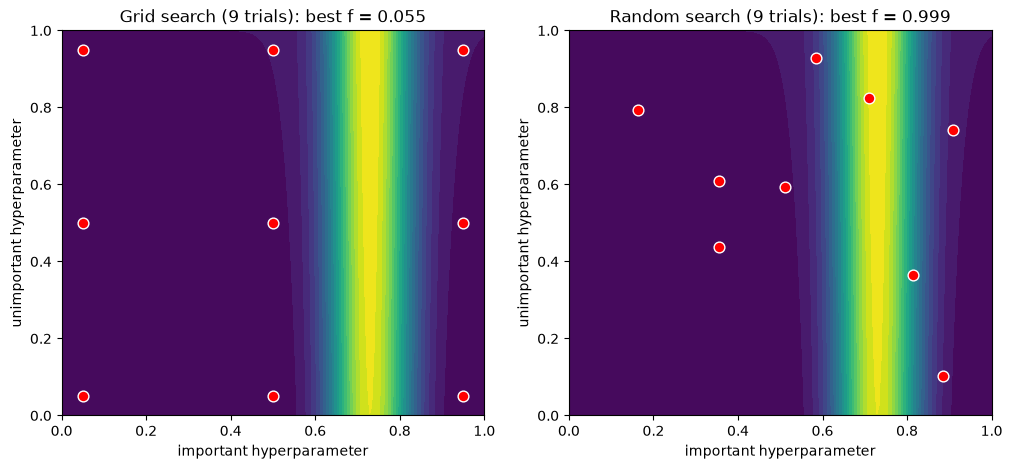

In [2]:
f = lambda a, b: np.exp(-((a - 0.73) ** 2) / 0.01) + 0.05 * b        # 'a' matters a lot, 'b' hardly
g = np.linspace(0.05, 0.95, 3); grid_pts = np.array([[a, b] for a in g for b in g]); rand_pts = rng.uniform(0.05, 0.95, (9, 2))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
A, B = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
for ax, pts, name in [(axes[0], grid_pts, "Grid search (9 trials)"), (axes[1], rand_pts, "Random search (9 trials)")]:
    ax.contourf(A, B, f(A, B), levels=20, cmap="viridis"); ax.scatter(*pts.T, c="r", s=60, edgecolor="w")
    best = pts[np.argmax(f(*pts.T))]
    ax.set(xlabel="important hyperparameter", ylabel="unimportant hyperparameter", title=f"{name}: best f = {f(*best):.3f}")
plt.show()

## **2. Grid vs Random vs Successive Halving vs Optuna on a Real Budget**
All methods get ~40 configurations of a gradient-boosting model with 6 hyperparameters.

In [3]:
space_random = {"learning_rate": loguniform(0.01, 0.3), "max_leaf_nodes": randint(8, 128), "min_samples_leaf": randint(5, 100),
                "l2_regularization": loguniform(1e-4, 10), "max_features": uniform(0.3, 0.7), "max_iter": randint(100, 600)}
results = {}

t = time.perf_counter()
grid = {"learning_rate": [0.03, 0.1], "max_leaf_nodes": [15, 63], "min_samples_leaf": [10, 50], "l2_regularization": [0.01, 1.0],
        "max_features": [0.5, 1.0], "max_iter": [200]}                                        # 2^5 = 32 configs
gs = GridSearchCV(HistGradientBoostingClassifier(random_state=0), grid, cv=cv, scoring="roc_auc", n_jobs=-1).fit(X, y)
results["Grid (32)"] = (gs.best_score_, time.perf_counter() - t)

t = time.perf_counter()
rs = RandomizedSearchCV(HistGradientBoostingClassifier(random_state=0), space_random, n_iter=40, cv=cv, scoring="roc_auc", random_state=0, n_jobs=-1).fit(X, y)
results["Random (40)"] = (rs.best_score_, time.perf_counter() - t)

t = time.perf_counter()
hs = HalvingRandomSearchCV(HistGradientBoostingClassifier(random_state=0), space_random, n_candidates=81, factor=3, resource="n_samples",
                           cv=cv, scoring="roc_auc", random_state=0, n_jobs=-1).fit(X, y)
results["Successive halving (81 start)"] = (hs.best_score_, time.perf_counter() - t)

def objective(trial):
    params = {"learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
              "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 8, 128, log=True),
              "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 100, log=True),
              "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 10, log=True),
              "max_features": trial.suggest_float("max_features", 0.3, 1.0),
              "max_iter": trial.suggest_int("max_iter", 100, 600, step=50)}
    return evaluate(params)

t = time.perf_counter()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective, n_trials=40)
results["Optuna TPE (40)"] = (study.best_value, time.perf_counter() - t)
pd.DataFrame(results, index=["best CV AUC", "seconds"]).T.round(4)

,best CV AUC,seconds
Grid (32),0.9539,10.6293
Random (40),0.9539,17.8844
Successive halving (81 start),0.9287,9.1972
Optuna TPE (40),0.9554,69.5885


Note: halving's `best_score_` is measured on its final (largest) resource level, which may be a subset; compare finalists on equal footing before trusting small differences.

### How the search progressed

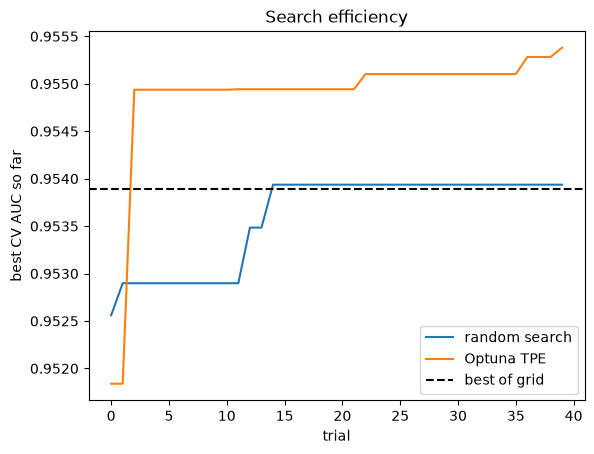

In [4]:
rs_curve = np.maximum.accumulate(rs.cv_results_["mean_test_score"])
opt_curve = np.maximum.accumulate([t_.value for t_ in study.trials])
plt.plot(rs_curve, label="random search"); plt.plot(opt_curve, label="Optuna TPE")
plt.axhline(gs.best_score_, c="k", ls="--", label="best of grid")
plt.xlabel("trial"); plt.ylabel("best CV AUC so far"); plt.legend(); plt.title("Search efficiency"); plt.show()

## **3. Inspecting an Optuna Study**
Which hyperparameters mattered? Optuna estimates importance with fANOVA-style analysis.

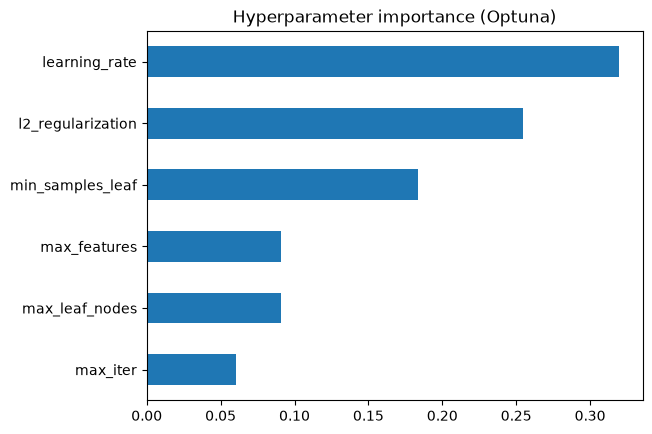

best params: {'learning_rate': 0.0225, 'max_leaf_nodes': 76, 'min_samples_leaf': 5, 'l2_regularization': 0.0002, 'max_features': 0.3724, 'max_iter': 600}


In [5]:
imp = optuna.importance.get_param_importances(study)
pd.Series(imp).sort_values().plot.barh(title="Hyperparameter importance (Optuna)"); plt.show()
print("best params:", {k: round(v, 4) if isinstance(v, float) else v for k, v in study.best_params.items()})

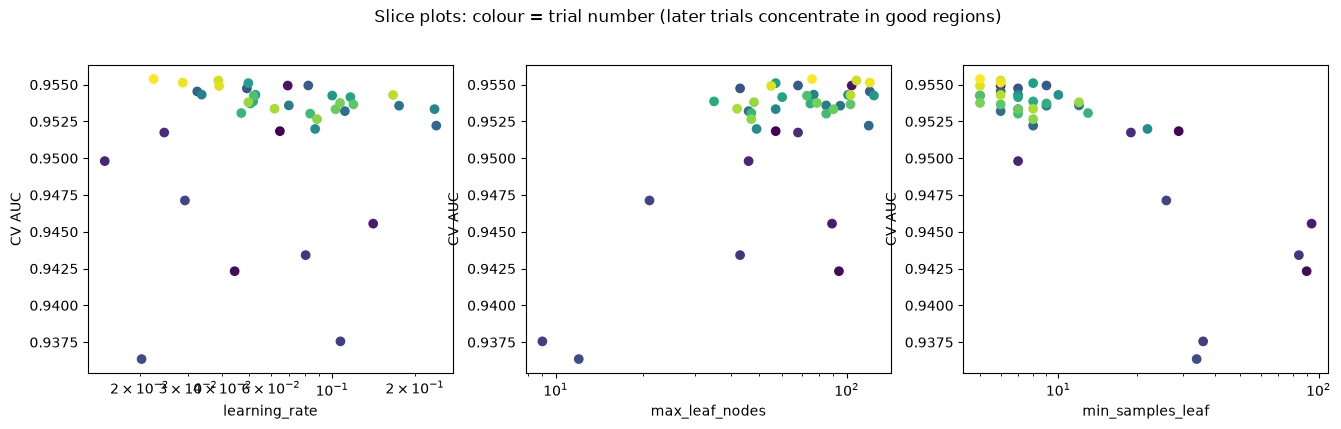

In [6]:
df_trials = study.trials_dataframe()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, p_ in zip(axes, ["params_learning_rate", "params_max_leaf_nodes", "params_min_samples_leaf"]):
    ax.scatter(df_trials[p_], df_trials.value, c=df_trials.number, cmap="viridis"); ax.set_xscale("log"); ax.set(xlabel=p_.replace("params_", ""), ylabel="CV AUC")
plt.suptitle("Slice plots: colour = trial number (later trials concentrate in good regions)", y=1.02); plt.show()

## **4. Search-Space Design Rules**
- Use **log scales** for scale-type parameters (learning rate, C, gamma, regularisation): 0.001 -> 0.01 is as big a change as 0.1 -> 1.
- Use **integer** distributions for counts; keep ranges wide at first, then narrow.
- **Conditional** parameters: e.g. `degree` only if `kernel == "poly"` (Optuna handles this naturally with `if` statements).
- Tune the number of boosting rounds with **early stopping**, not as a searched parameter.
- **Fix all seeds**; record the full search (Day 81).

In [7]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
def svm_objective(trial):
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly"])
    params = {"C": trial.suggest_float("C", 1e-3, 1e3, log=True), "kernel": kernel}
    if kernel in ("rbf", "poly"):
        params["gamma"] = trial.suggest_float("gamma", 1e-4, 1, log=True)
    if kernel == "poly":
        params["degree"] = trial.suggest_int("degree", 2, 4)
    return cross_val_score(make_pipeline(StandardScaler(), SVC(**params)), X[:1500], y[:1500], cv=3).mean()
svm_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=1))
svm_study.optimize(svm_objective, n_trials=30)
print("conditional search best:", svm_study.best_params, "accuracy", round(svm_study.best_value, 4))

conditional search best: {'kernel': 'rbf', 'C': 94.4608367969363, 'gamma': 0.07789178893844421} accuracy 0.886


## **5. Pruning: Stop Bad Trials Early**
For iterative models, report intermediate scores; a pruner stops trials that are clearly worse than others at the same step.

In [8]:
from sklearn.linear_model import SGDClassifier
def sgd_objective(trial):
    alpha = trial.suggest_float("alpha", 1e-6, 1e-1, log=True); eta0 = trial.suggest_float("eta0", 1e-4, 1e-1, log=True)
    clf = SGDClassifier(loss="log_loss", alpha=alpha, learning_rate="constant", eta0=eta0, random_state=0)
    Xa, ya, Xv, yv = X[:2000], y[:2000], X[2000:], y[2000:]
    for step in range(30):
        clf.partial_fit(Xa, ya, classes=[0, 1])
        score = clf.score(Xv, yv); trial.report(score, step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return score
pr_study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=5), sampler=optuna.samplers.TPESampler(seed=0))
pr_study.optimize(sgd_objective, n_trials=40)
n_pruned = sum(t_.state == optuna.trial.TrialState.PRUNED for t_ in pr_study.trials)
print(f"{n_pruned} of 40 trials pruned early | best accuracy {pr_study.best_value:.4f}")

12 of 40 trials pruned early | best accuracy 0.7000


## **6. Don't Overfit the Validation Set**
Trying hundreds of configurations on the same CV folds overfits them (the best score is the maximum of many noisy estimates). Remedies: **nested CV** (Day 40) or a final **untouched test set**; prefer simpler configurations among near-ties; report the tuning budget.

# **Part 2: Going Deeper - Bayesian Optimisation From Scratch**

1. Fit a **surrogate** (Gaussian process, Day 54) to the evaluated (hyperparameter, score) pairs; it gives a mean $\mu(x)$ and uncertainty $\sigma(x)$ everywhere.
2. Choose the next point by maximising an **acquisition function** that trades off exploitation (high $\mu$) and exploration (high $\sigma$). **Expected Improvement**:
$$EI(x) = (\mu - f^* - \xi)\Phi(z) + \sigma\phi(z),\qquad z = \frac{\mu - f^* - \xi}{\sigma}$$

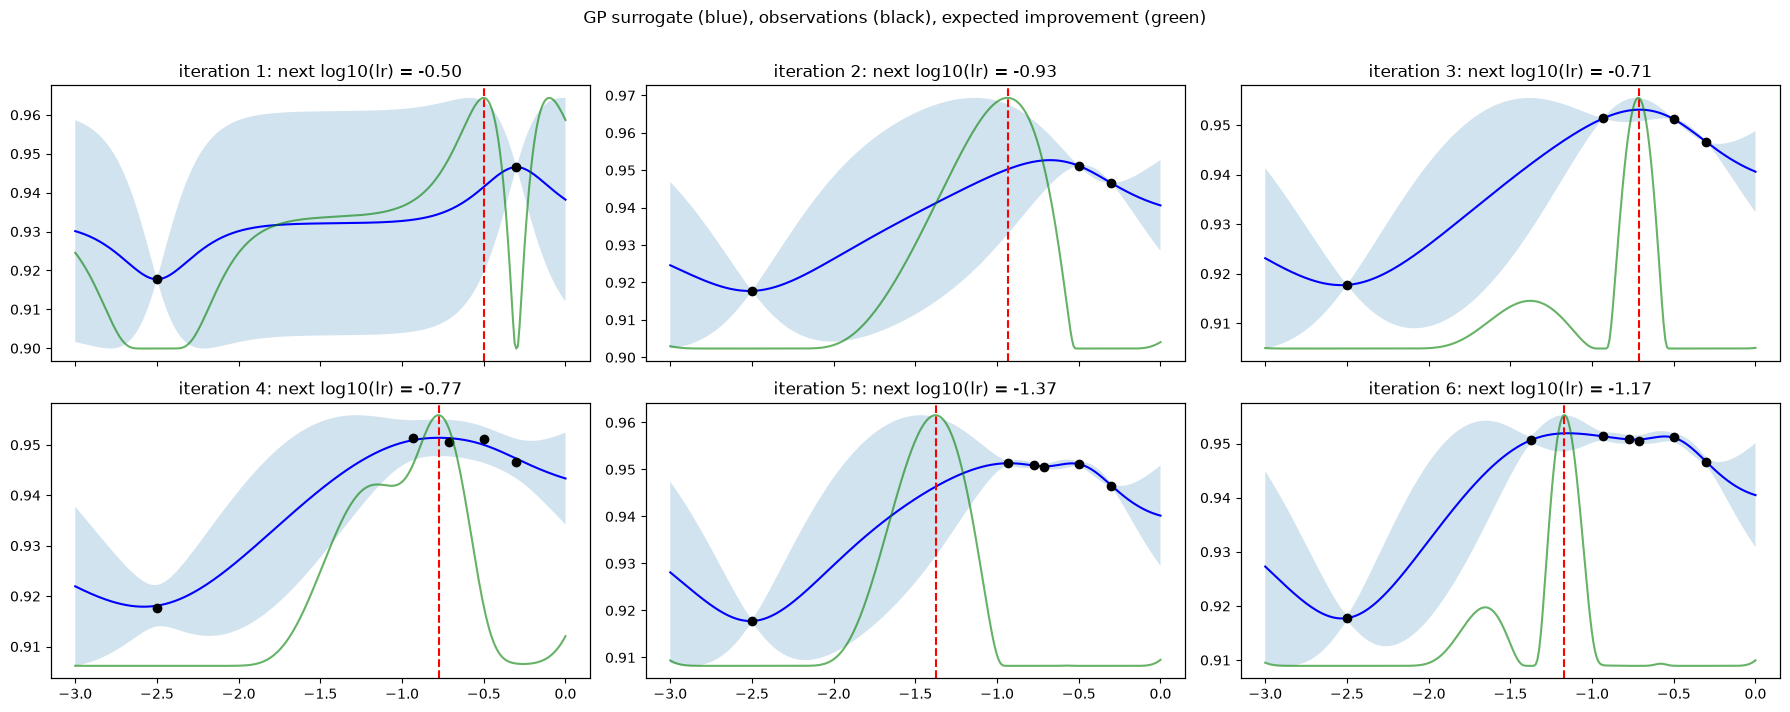

best learning rate found: 0.0670, AUC 0.9517


In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from scipy.stats import norm
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)   # GP hyperparameters at bounds are harmless here

def black_box(log_lr):                                 # 1-D tuning problem: log10(learning_rate)
    return evaluate({"learning_rate": 10 ** log_lr, "max_iter": 200})

def expected_improvement(mu, sd, best, xi=0.001):
    z = (mu - best - xi) / (sd + 1e-12); return (mu - best - xi) * norm.cdf(z) + sd * norm.pdf(z)

grid_x = np.linspace(-3, 0, 300)[:, None]
X_obs = np.array([[-2.5], [-0.3]]); y_obs = np.array([black_box(v[0]) for v in X_obs])
fig, axes = plt.subplots(2, 3, figsize=(18, 7), sharex=True)
for it in range(6):
    gp = GaussianProcessRegressor(Matern(length_scale=0.5, nu=2.5) + WhiteKernel(1e-5), normalize_y=True).fit(X_obs, y_obs)
    mu, sd = gp.predict(grid_x, return_std=True); ei = expected_improvement(mu, sd, y_obs.max())
    ax = axes.ravel()[it]
    ax.plot(grid_x, mu, "b"); ax.fill_between(grid_x.ravel(), mu - 2 * sd, mu + 2 * sd, alpha=0.2); ax.scatter(X_obs, y_obs, c="k", zorder=3)
    ax2 = ax.twinx(); ax2.plot(grid_x, ei, "g", alpha=0.6); ax2.set_yticks([])
    x_next = grid_x[np.argmax(ei)]; ax.axvline(x_next[0], c="r", ls="--"); ax.set_title(f"iteration {it + 1}: next log10(lr) = {x_next[0]:.2f}")
    X_obs = np.vstack([X_obs, x_next]); y_obs = np.append(y_obs, black_box(x_next[0]))
plt.suptitle("GP surrogate (blue), observations (black), expected improvement (green)", y=1.01); plt.tight_layout(); plt.show()
print(f"best learning rate found: {10 ** X_obs[np.argmax(y_obs)][0]:.4f}, AUC {y_obs.max():.4f}")

## **Practice Problems**
1. Re-run the random search with 10 and 60 iterations. How much does the best score improve?
2. Tune a `RandomForestClassifier` with Optuna (`max_features`, `min_samples_leaf`, `max_depth`). Is tuning RF worth it compared with defaults?
3. Use `optuna.samplers.RandomSampler` vs `TPESampler` with 2 seeds each and compare mean best scores after 20 trials.
4. *(Advanced)* Replace Expected Improvement by the **Upper Confidence Bound** $\mu + \kappa\sigma$ with $\kappa = 2$ in the scratch Bayesian optimiser.

In [10]:
# Solution 1
for n_iter in [10, 60]:
    r = RandomizedSearchCV(HistGradientBoostingClassifier(random_state=0), space_random, n_iter=n_iter, cv=cv, scoring="roc_auc", random_state=0, n_jobs=-1).fit(X, y)
    print(f"random search {n_iter} iterations: best {r.best_score_:.4f}")
# Solution 2
from sklearn.ensemble import RandomForestClassifier
def rf_obj(trial):
    p = {"max_features": trial.suggest_float("max_features", 0.1, 1.0), "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30, log=True),
         "max_depth": trial.suggest_int("max_depth", 4, 40, log=True)}
    return cross_val_score(RandomForestClassifier(200, n_jobs=-1, random_state=0, **p), X, y, cv=cv, scoring="roc_auc").mean()
rf_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=0)); rf_study.optimize(rf_obj, n_trials=10)
print(f"RF default AUC {cross_val_score(RandomForestClassifier(200, n_jobs=-1, random_state=0), X, y, cv=cv, scoring='roc_auc').mean():.4f} | tuned {rf_study.best_value:.4f}")
# Solution 3
for name, sampler_cls in [("random", optuna.samplers.RandomSampler), ("TPE", optuna.samplers.TPESampler)]:
    bests = []
    for seed in range(2):
        st_ = optuna.create_study(direction="maximize", sampler=sampler_cls(seed=seed)); st_.optimize(objective, n_trials=20); bests.append(st_.best_value)
    print(f"{name:<6} mean best AUC after 20 trials (2 seeds): {np.mean(bests):.4f} +/- {np.std(bests):.4f}")
# Solution 4
X_u = np.array([[-2.5], [-0.3]]); y_u = np.array([black_box(v[0]) for v in X_u])
for it in range(6):
    gp = GaussianProcessRegressor(Matern(length_scale=0.5, nu=2.5) + WhiteKernel(1e-5), normalize_y=True).fit(X_u, y_u)
    mu, sd = gp.predict(grid_x, return_std=True); x_next = grid_x[np.argmax(mu + 2 * sd)]
    X_u = np.vstack([X_u, x_next]); y_u = np.append(y_u, black_box(x_next[0]))
print(f"UCB best learning rate: {10 ** X_u[np.argmax(y_u)][0]:.4f}, AUC {y_u.max():.4f}")

random search 10 iterations: best 0.9529


random search 60 iterations: best 0.9539


RF default AUC 0.9483 | tuned 0.9483


random mean best AUC after 20 trials (2 seeds): 0.9543 +/- 0.0007


TPE    mean best AUC after 20 trials (2 seeds): 0.9548 +/- 0.0001


UCB best learning rate: 0.1470, AUC 0.9533


## **Key References**
- Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. *JMLR*, 13, 281-305.
- Snoek, J., Larochelle, H., & Adams, R. P. (2012). Practical Bayesian optimization of machine learning algorithms. *NeurIPS 25*.
- Bergstra, J., Bardenet, R., Bengio, Y., & Kegl, B. (2011). Algorithms for hyper-parameter optimization. *NeurIPS 24* (TPE).
- Li, L., Jamieson, K., DeSalvo, G., Rostamizadeh, A., & Talwalkar, A. (2018). Hyperband: A novel bandit-based approach to hyperparameter optimization. *JMLR*, 18(185), 1-52.
- Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). Optuna: A next-generation hyperparameter optimization framework. *KDD 2019*.
- Bischl, B. et al. (2023). Hyperparameter optimization: Foundations, algorithms, best practices, and open challenges. *WIREs Data Mining and Knowledge Discovery*, 13(2), e1484.